# 09 — Feature Engineering

**Author:** Zeineb Turki  
**Date:** April 2026  
**Phase:** 6 — Feature Engineering  

## Objective

Build a rich, event-level feature matrix for the Random Forest classifier.  
Each row corresponds to one detected technical event (S/R touch, multi-top/bottom, triangle, or channel).  
Every feature uses **only information available at or before the event bar** — no lookahead.

**Scope:**
1. Load data and compute the full feature matrix via `build_feature_matrix`
2. Catalogue all 32+ technical indicators with descriptions
3. Inspect the event-level feature matrix shape, sample rows, and summary statistics
4. Correlation analysis (heatmap of top features)
5. Class distribution of triple-barrier labels
6. Feature distributions by label class (violin / box plots per feature group)
7. Feature importance ranking via ANOVA F-statistic
8. Lookahead bias prevention discussion
9. Clean summary table of all features

In [1]:
import sys, os
from pathlib import Path

# Clear cached src modules for clean reload
for mod_name in list(sys.modules.keys()):
    if mod_name.startswith('src'):
        del sys.modules[mod_name]

# Environment setup (Colab / local)
if 'google.colab' in str(getattr(sys, 'modules', {})) or os.path.exists('/content'):
    REPO_DIR  = '/content/regime-aware-ml-trading'
    PROJ_ROOT = os.path.join(REPO_DIR, 'regime-aware-ml-trading')
    if not os.path.isdir(PROJ_ROOT):
        os.system('git clone https://github.com/zaetae/regime-aware-ml-trading.git ' + REPO_DIR)
    else:
        os.system(f'cd {REPO_DIR} && git pull -q')
    os.system(f'{sys.executable} -m pip install -q yfinance hmmlearn scikit-learn seaborn statsmodels')
    _spy_path = os.path.join(PROJ_ROOT, 'data', 'raw', 'spy.csv')
    if not os.path.isfile(_spy_path):
        os.makedirs(os.path.dirname(_spy_path), exist_ok=True)
        import yfinance as yf
        import pandas as pd
        _spy = yf.download('SPY', start='2010-01-01', end='2026-01-01', auto_adjust=False)
        if isinstance(_spy.columns, pd.MultiIndex):
            _spy.columns = _spy.columns.droplevel(1)
        _spy = _spy[['Open', 'High', 'Low', 'Close', 'Volume']]
        if _spy.index.tz is not None:
            _spy.index = _spy.index.tz_localize(None)
        _spy.index.name = 'Date'
        _spy.to_csv(_spy_path)
        print(f'Downloaded SPY data to {_spy_path}')
else:
    def _find_project_root():
        current = Path.cwd()
        for _ in range(10):
            if (current / 'src').is_dir():
                return current
            current = current.parent
        return Path.cwd().parent if (Path.cwd().parent / 'src').is_dir() else Path.cwd()
    PROJ_ROOT = str(_find_project_root())

sys.path.insert(0, PROJ_ROOT)
os.chdir(PROJ_ROOT)

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data.load_data import load_spy
from src.features.build_features import build_feature_matrix
from src.features.indicators import compute_all_indicators

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = load_spy()
print(f'Loaded {len(df)} bars: {df.index[0].date()} to {df.index[-1].date()}')
print('Imports OK')

Loaded 4023 bars: 2010-01-04 to 2025-12-30
Imports OK


---

## 1. Compute All Bar-Level Technical Indicators

Before building the event matrix, we first compute all 32+ indicators on the full bar-level
OHLCV dataset. This lets us inspect what each feature looks like across the entire price history.

`compute_all_indicators(df)` returns a DataFrame with one column per indicator.
Every value at bar *i* uses only data at or before bar *i* (no lookahead).

In [2]:
indicators = compute_all_indicators(df)
print(f'Indicator matrix shape: {indicators.shape}')
print(f'  Rows (bars):     {indicators.shape[0]}')
print(f'  Columns (feats): {indicators.shape[1]}')
print()
print('All indicator columns:')
for i, col in enumerate(indicators.columns, 1):
    print(f'  {i:2d}. {col}')

Indicator matrix shape: (4023, 32)
  Rows (bars):     4023
  Columns (feats): 32

All indicator columns:
   1. atr_14
   2. atr_ratio
   3. rvol_20
   4. ret_1
   5. ret_5
   6. ret_10
   7. ret_20
   8. sma_10
   9. sma_10_dist
  10. sma_20
  11. sma_20_dist
  12. sma_50
  13. sma_50_dist
  14. sma_100
  15. sma_100_dist
  16. sma_200
  17. sma_200_dist
  18. ma_spread_10_50
  19. ma_spread_20_200
  20. ma_spread_50_200
  21. rsi_14
  22. macd
  23. macd_signal
  24. macd_hist
  25. bb_width
  26. bb_pctb
  27. mom_5
  28. mom_10
  29. mom_20
  30. volume_ratio
  31. volume_std
  32. obv_norm


### Indicator Catalogue

The table below lists every technical indicator computed by `compute_all_indicators`,
grouped by category. Each uses only past data (no lookahead).

| # | Feature | Group | Description | Why Useful |
|--:|---------|-------|-------------|------------|
| 1 | `atr_14` | Volatility | 14-bar Average True Range | Absolute volatility level; scales barrier widths |
| 2 | `atr_ratio` | Volatility | ATR / Close | Normalised volatility, comparable across price levels |
| 3 | `rvol_20` | Volatility | 20-bar annualised rolling volatility of log returns | Regime indicator: low vol = trend, high vol = chop |
| 4 | `ret_1` | Momentum | 1-bar simple return | Immediate price action before event |
| 5 | `ret_5` | Momentum | 5-bar simple return | Short-term trend direction |
| 6 | `ret_10` | Momentum | 10-bar simple return | Medium-term trend context |
| 7 | `ret_20` | Momentum | 20-bar simple return | Monthly trend context |
| 8 | `sma_10` | Trend | 10-bar simple moving average | Short-term trend level |
| 9 | `sma_10_dist` | Trend | (Close - SMA10) / SMA10 | Distance from short-term average (mean-reversion signal) |
| 10 | `sma_20` | Trend | 20-bar simple moving average | Medium-term trend level |
| 11 | `sma_20_dist` | Trend | (Close - SMA20) / SMA20 | Extension from 20-day mean |
| 12 | `sma_50` | Trend | 50-bar simple moving average | Intermediate trend |
| 13 | `sma_50_dist` | Trend | (Close - SMA50) / SMA50 | Extension from 50-day mean |
| 14 | `sma_100` | Trend | 100-bar simple moving average | Long-term trend |
| 15 | `sma_100_dist` | Trend | (Close - SMA100) / SMA100 | Extension from 100-day mean |
| 16 | `sma_200` | Trend | 200-bar simple moving average | Major trend (bull/bear dividing line) |
| 17 | `sma_200_dist` | Trend | (Close - SMA200) / SMA200 | Distance from 200-day; positive = bullish regime |
| 18 | `ma_spread_10_50` | Trend | (SMA10 - SMA50) / SMA50 | Short vs intermediate trend alignment |
| 19 | `ma_spread_20_200` | Trend | (SMA20 - SMA200) / SMA200 | Medium vs long-term alignment (golden/death cross proxy) |
| 20 | `ma_spread_50_200` | Trend | (SMA50 - SMA200) / SMA200 | Classic golden/death cross spread |
| 21 | `rsi_14` | Momentum | 14-bar Relative Strength Index | Overbought (>70) / oversold (<30) gauge |
| 22 | `macd` | Momentum | MACD line (EMA12 - EMA26) | Trend direction and momentum |
| 23 | `macd_signal` | Momentum | 9-bar EMA of MACD line | Smoothed momentum; crossovers signal turns |
| 24 | `macd_hist` | Momentum | MACD - Signal | Momentum acceleration/deceleration |
| 25 | `bb_width` | Volatility | Bollinger Band width / SMA20 | Volatility squeeze detection |
| 26 | `bb_pctb` | Volatility | %B (position within Bollinger Bands) | Where price sits in volatility envelope |
| 27 | `mom_5` | Momentum | 5-bar rate of change | Short-term price momentum |
| 28 | `mom_10` | Momentum | 10-bar rate of change | Medium-term price momentum |
| 29 | `mom_20` | Momentum | 20-bar rate of change | Longer-term price momentum |
| 30 | `volume_ratio` | Volume | Volume / 20-bar volume MA | Relative volume (high = institutional interest) |
| 31 | `volume_std` | Volume | Volume rolling std / volume MA | Volume variability (unusual activity) |
| 32 | `obv_norm` | Volume | Normalised on-balance volume | Accumulation/distribution pressure |

In [3]:
# Quick peek at the first and last rows
print('First 5 rows (NaN expected due to rolling windows):')
indicators.head().round(4)

First 5 rows (NaN expected due to rolling windows):


,atr_14,atr_ratio,rvol_20,ret_1,ret_5,ret_10,ret_20,sma_10,sma_10_dist,sma_20,...,macd_signal,macd_hist,bb_width,bb_pctb,mom_5,mom_10,mom_20,volume_ratio,volume_std,obv_norm
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,0.0026,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0036,0.0144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,0.0007,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0102,0.0264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,0.0042,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0241,0.0555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,0.0033,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0462,0.0887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print('Last 5 rows:')
indicators.tail().round(4)

Last 5 rows:


,atr_14,atr_ratio,rvol_20,ret_1,ret_5,ret_10,ret_20,sma_10,sma_10_dist,sma_20,...,macd_signal,macd_hist,bb_width,bb_pctb,mom_5,mom_10,mom_20,volume_ratio,volume_std,obv_norm
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,6.2380,0.0091,0.0937,0.0046,0.0164,0.0102,0.0318,680.5309,0.0109,680.2872,...,2.4014,0.2223,0.0272,0.9148,0.0164,0.0102,0.0318,0.8138,0.2776,7.2526
2025-12-24,6.1674,0.0089,0.0894,0.0035,0.0313,0.0071,0.0258,681.0144,0.0138,681.1546,...,2.5667,0.6612,0.0283,0.9790,0.0313,0.0071,0.0258,0.5084,0.3076,7.4726
2025-12-26,6.0532,0.0088,0.0870,-0.0001,0.0235,0.0046,0.0186,681.3315,0.0132,681.7863,...,2.7851,0.8737,0.0302,0.9136,0.0235,0.0046,0.0186,0.5470,0.3309,7.5939
2025-12-29,5.9950,0.0087,0.0867,-0.0036,0.0107,0.0119,0.0095,682.1413,0.0084,682.1099,...,2.9798,0.7788,0.0312,0.7695,0.0107,0.0119,0.0095,0.8152,0.3204,7.4871
2025-12-30,5.9370,0.0086,0.0849,-0.0012,0.0032,0.0122,0.0129,682.9699,0.0059,682.5471,...,3.1292,0.5976,0.0314,0.7085,0.0032,0.0122,0.0129,0.6202,0.3321,7.5252


In [5]:
# Missing value count per column (due to rolling window warm-up)
missing = indicators.isna().sum().sort_values(ascending=False)
print('Missing values per indicator (from rolling warm-up):')
print(missing[missing > 0].to_string())
print(f'\nTotal bars: {len(indicators)}')
print(f'Fully valid rows (no NaN): {indicators.dropna().shape[0]}')

Missing values per indicator (from rolling warm-up):
sma_200_dist        199
ma_spread_50_200    199
ma_spread_20_200    199
sma_200             199
sma_100              99
sma_100_dist         99
ma_spread_10_50      49
sma_50               49
sma_50_dist          49
rvol_20              20
mom_20               20
ret_20               20
volume_std           19
volume_ratio         19
bb_pctb              19
bb_width             19
obv_norm             19
sma_20_dist          19
sma_20               19
rsi_14               15
atr_ratio            13
atr_14               13
mom_10               10
ret_10               10
sma_10_dist           9
sma_10                9
mom_5                 5
ret_5                 5
ret_1                 1

Total bars: 4023
Fully valid rows (no NaN): 3824


---

## 2. Build the Event-Level Feature Matrix

The `build_feature_matrix` function:
1. Computes all bar-level indicators
2. Runs the pattern scanner to detect events
3. Labels events with triple-barrier method
4. For each event, extracts the bar-level indicator values **at the event date**
5. Appends pattern geometry features (slopes, touches, containment)
6. Appends event-type dummy variables

The result is one row per event, with 40+ feature columns and a label.

In [6]:
features, labels, labeled_df = build_feature_matrix(df)

print(f'Feature matrix shape: {features.shape}')
print(f'  Events (rows):   {features.shape[0]}')
print(f'  Features (cols): {features.shape[1]}')
print(f'\nLabel distribution:')
print(labels.value_counts().to_string())
print(f'\nAll feature columns ({features.shape[1]}):')
for i, col in enumerate(features.columns, 1):
    print(f'  {i:2d}. {col}')

Feature matrix shape: (221, 55)
  Events (rows):   221
  Features (cols): 55

Label distribution:
label
long        88
no_trade    69
short       64

All feature columns (55):
   1. atr_14
   2. atr_ratio
   3. rvol_20
   4. ret_1
   5. ret_5
   6. ret_10
   7. ret_20
   8. sma_10
   9. sma_10_dist
  10. sma_20
  11. sma_20_dist
  12. sma_50
  13. sma_50_dist
  14. sma_100
  15. sma_100_dist
  16. sma_200
  17. sma_200_dist
  18. ma_spread_10_50
  19. ma_spread_20_200
  20. ma_spread_50_200
  21. rsi_14
  22. macd
  23. macd_signal
  24. macd_hist
  25. bb_width
  26. bb_pctb
  27. mom_5
  28. mom_10
  29. mom_20
  30. volume_ratio
  31. volume_std
  32. obv_norm
  33. upper_slope
  34. lower_slope
  35. containment
  36. upper_touches
  37. lower_touches
  38. total_touches
  39. upper_mean_error
  40. lower_mean_error
  41. pattern_window
  42. channel_width_atr
  43. r_upper
  44. r_lower
  45. etype_ascending_triangle
  46. etype_channel_down
  47. etype_channel_up
  48. etype_desc

In [7]:
# Sample rows from the feature matrix
print('Sample rows (first 5):')
features.head()

Sample rows (first 5):


,atr_14,atr_ratio,rvol_20,ret_1,ret_5,ret_10,ret_20,sma_10,sma_10_dist,sma_20,...,etype_channel_down,etype_channel_up,etype_descending_triangle,etype_multiple_bottom,etype_multiple_top,etype_near_resistance,etype_near_support,etype_symmetric_triangle,entry_price,event_atr
0,0.841608,0.009218,0.077676,0.011349,0.023910,0.032283,0.045349,89.652656,0.018369,88.820185,...,False,True,False,False,False,False,False,False,91.30,0.8416
1,1.187616,0.013268,0.153671,-0.016962,-0.024629,-0.004608,0.008573,90.633523,-0.012435,90.363445,...,False,True,False,False,False,False,False,False,89.51,1.1876
2,2.157829,0.025872,0.327608,0.003444,0.033032,-0.009395,-0.052303,81.969160,0.017508,83.987405,...,True,False,False,False,False,False,False,False,83.40,2.1578
3,1.960881,0.023768,0.297651,-0.001550,0.038108,0.001280,-0.038458,81.505085,0.012210,82.096473,...,False,False,False,False,False,False,False,True,82.50,1.9609
4,1.473236,0.018920,0.207807,0.006556,-0.043337,-0.076654,-0.020197,79.999747,-0.026663,81.483988,...,False,False,False,False,True,False,False,False,77.87,1.4732


In [8]:
# Sample rows from the labeled events (metadata)
print('Labeled events (first 5):')
labeled_df[['event_date', 'event_type', 'entry_price', 'label', 'return_pct', 'bars_held']].head()

Labeled events (first 5):


,event_date,event_type,entry_price,label,return_pct,bars_held
0,2010-04-14,channel_up,91.30,short,-1.8436,2
1,2010-04-30,channel_up,89.51,short,-2.6537,4
2,2010-06-03,channel_down,83.40,short,-5.1744,3
3,2010-06-14,symmetric_triangle,82.50,no_trade,-1.3409,10
4,2010-07-06,multiple_top,77.87,long,3.7840,2


---

## 3. Feature Statistics

Descriptive statistics for every feature column: mean, std, min, max, and missing count.

In [9]:
# Compute descriptive statistics
desc = features.describe().T
desc['missing'] = features.isna().sum()
desc['missing_%'] = (features.isna().sum() / len(features) * 100).round(1)

print(f'Feature statistics ({len(desc)} features):')
desc[['count', 'mean', 'std', 'min', 'max', 'missing', 'missing_%']].round(4)

Feature statistics (46 features):


,count,mean,std,min,max,missing,missing_%
atr_14,221.0,3.5976,3.1143,0.7104,24.1561,0,0.0
atr_ratio,221.0,0.0128,0.0079,0.0040,0.0793,0,0.0
rvol_20,221.0,0.1450,0.0913,0.0383,0.9099,0,0.0
ret_1,221.0,0.0022,0.0129,-0.0781,0.0906,0,0.0
ret_5,221.0,0.0028,0.0242,-0.1128,0.0567,0,0.0
ret_10,221.0,0.0025,0.0337,-0.1520,0.0980,0,0.0
ret_20,221.0,0.0043,0.0412,-0.2177,0.0737,0,0.0
sma_10,221.0,277.0404,156.8782,79.9997,681.2948,0,0.0
sma_10_dist,221.0,0.0022,0.0184,-0.0902,0.0336,0,0.0
sma_20,221.0,276.9787,156.6005,81.4840,675.2337,0,0.0


In [10]:
# Highlight features with high missing rates
high_missing = desc[desc['missing_%'] > 10][['missing', 'missing_%']].sort_values('missing_%', ascending=False)
if len(high_missing) > 0:
    print('Features with >10% missing values:')
    print(high_missing.to_string())
    print('\nNote: Pattern geometry features are NaN for S/R events (which have no geometry).')
else:
    print('No features with >10% missing values.')

Features with >10% missing values:
                   missing  missing_%
r_upper                199       90.0
r_lower                199       90.0
channel_width_atr      122       55.2
upper_slope            100       45.2
lower_slope            100       45.2
containment            100       45.2
upper_touches          100       45.2
lower_touches          100       45.2
total_touches          100       45.2
upper_mean_error       100       45.2
lower_mean_error       100       45.2
pattern_window         100       45.2

Note: Pattern geometry features are NaN for S/R events (which have no geometry).


---

## 4. Correlation Heatmap

Highly correlated features carry redundant information and can cause issues for some models.
We visualise the pairwise Pearson correlation among the numeric indicator features
(excluding event-type dummies and pattern geometry, which are often sparse).

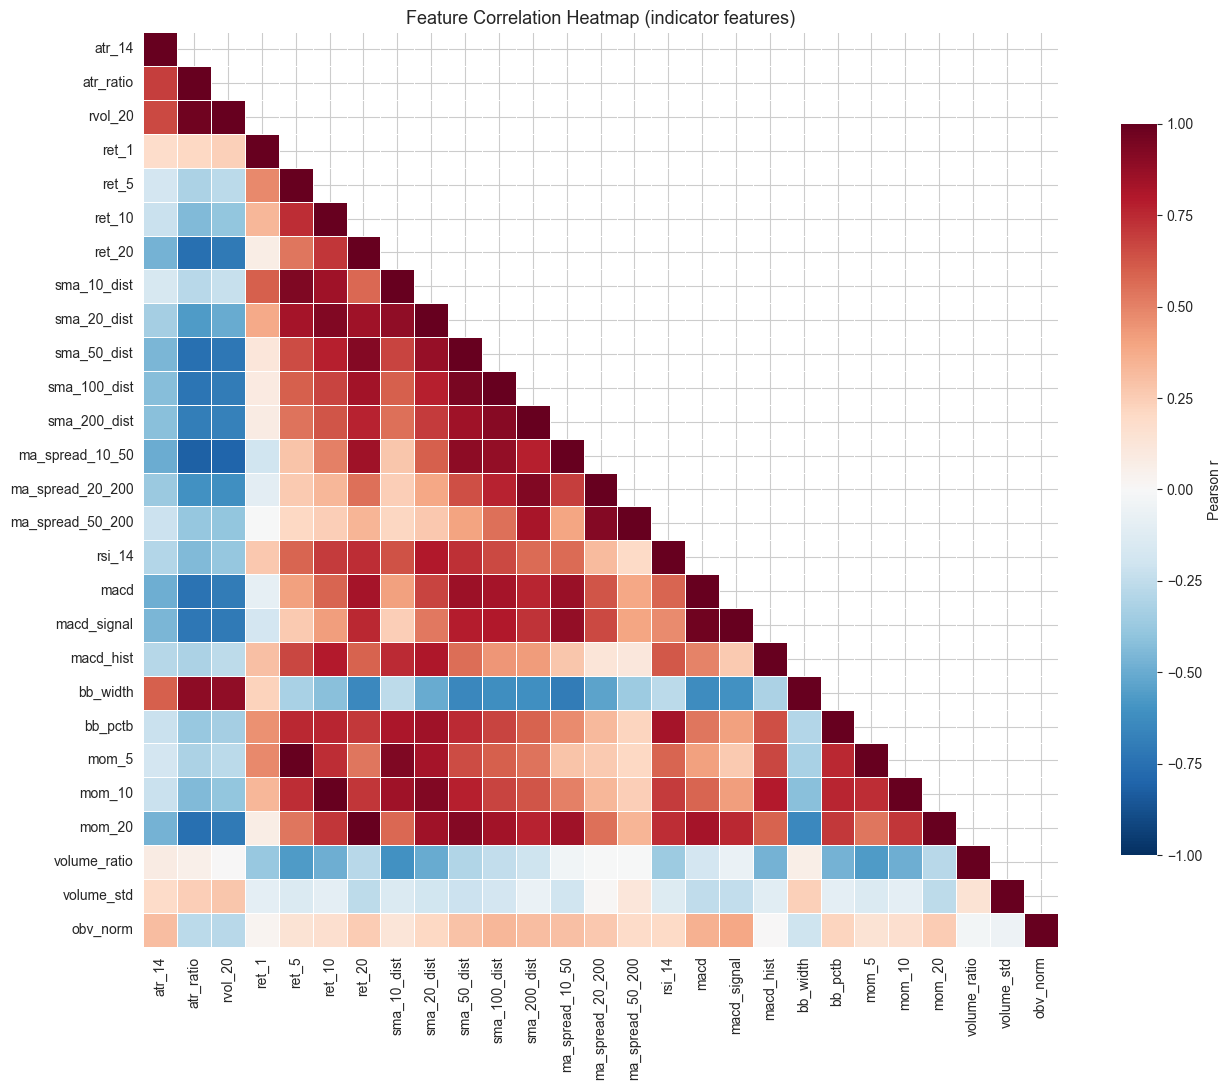

In [11]:
# Select only numeric indicator columns (exclude dummies and sparse geometry)
indicator_cols = [
    'atr_14', 'atr_ratio', 'rvol_20',
    'ret_1', 'ret_5', 'ret_10', 'ret_20',
    'sma_10_dist', 'sma_20_dist', 'sma_50_dist', 'sma_100_dist', 'sma_200_dist',
    'ma_spread_10_50', 'ma_spread_20_200', 'ma_spread_50_200',
    'rsi_14', 'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_pctb',
    'mom_5', 'mom_10', 'mom_20',
    'volume_ratio', 'volume_std', 'obv_norm',
]
# Keep only columns actually present in the feature matrix
indicator_cols = [c for c in indicator_cols if c in features.columns]

corr = features[indicator_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, fmt='.2f',
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'},
            ax=ax)
ax.set_title('Feature Correlation Heatmap (indicator features)', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# List highly correlated pairs (|r| > 0.85)
pairs = []
for i in range(len(corr)):
    for j in range(i + 1, len(corr)):
        r = corr.iloc[i, j]
        if abs(r) > 0.85:
            pairs.append((corr.index[i], corr.columns[j], round(r, 3)))

pairs_df = pd.DataFrame(pairs, columns=['Feature A', 'Feature B', 'Correlation'])
pairs_df = pairs_df.sort_values('Correlation', key=abs, ascending=False).reset_index(drop=True)

print(f'Highly correlated pairs (|r| > 0.85): {len(pairs_df)}')
if len(pairs_df) > 0:
    print(pairs_df.to_string(index=False))
else:
    print('None found.')

print('\nNote: High correlation between SMA distances and MA spreads is expected.')
print('Random Forests handle correlated features gracefully, but we document them for transparency.')

Highly correlated pairs (|r| > 0.85): 26
       Feature A        Feature B  Correlation
           ret_5            mom_5        1.000
          ret_20           mom_20        1.000
          ret_10           mom_10        1.000
       atr_ratio          rvol_20        0.975
            macd      macd_signal        0.969
     sma_50_dist     sma_100_dist        0.950
     sma_10_dist            mom_5        0.937
           ret_5      sma_10_dist        0.937
    sma_200_dist ma_spread_20_200        0.929
          ret_10      sma_20_dist        0.927
     sma_20_dist           mom_10        0.927
ma_spread_20_200 ma_spread_50_200        0.921
     sma_50_dist           mom_20        0.915
          ret_20      sma_50_dist        0.915
    sma_100_dist     sma_200_dist        0.908
     sma_50_dist  ma_spread_10_50        0.896
       atr_ratio         bb_width        0.892
         rvol_20         bb_width        0.890
     sma_10_dist      sma_20_dist        0.886
    sma_100_dist  m

---

## 5. Class Distribution of Labels

The triple-barrier labels (long / short / no_trade) serve as our classification target.
Reasonable class balance is important for training.

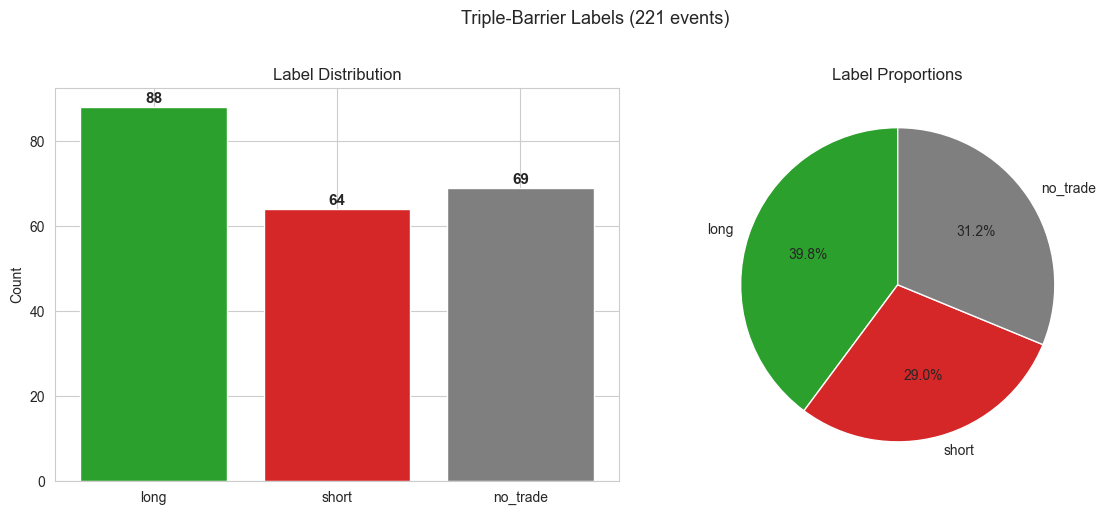

Label counts:
  long          88  (39.8%)
  short         64  (29.0%)
  no_trade      69  (31.2%)


In [13]:
label_order = ['long', 'short', 'no_trade']
colors = {'long': '#2ca02c', 'short': '#d62728', 'no_trade': '#7f7f7f'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = labels.value_counts().reindex(label_order, fill_value=0)
bars = axes[0].bar(counts.index, counts.values,
                   color=[colors[l] for l in counts.index], edgecolor='white')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(v), ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Label Distribution')

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=[colors[l] for l in counts.index], startangle=90)
axes[1].set_title('Label Proportions')

plt.suptitle(f'Triple-Barrier Labels ({len(labels)} events)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Label counts:')
for lbl in label_order:
    n = (labels == lbl).sum()
    print(f'  {lbl:10s}  {n:>4}  ({n / len(labels) * 100:.1f}%)')

---

## 6. Feature Distributions by Label Class

For each feature group we plot violin/box plots split by label.
Features that show clear separation between classes are likely to be informative for the classifier.

### 6.1 Trend Features

In [14]:
# Helper: merge features with labels for plotting
plot_df = features.copy()
plot_df['label'] = labels.values

def violin_grid(feature_list, title, ncols=3, figsize=(14, 6)):
    """Plot violin plots for a list of features, split by label."""
    # Filter to features actually present
    feature_list = [f for f in feature_list if f in plot_df.columns]
    if not feature_list:
        print(f'No features available for: {title}')
        return
    nrows = int(np.ceil(len(feature_list) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0], figsize[1] * nrows))
    axes = np.atleast_2d(axes)
    
    for idx, feat in enumerate(feature_list):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        data = plot_df[[feat, 'label']].dropna()
        if len(data) == 0:
            ax.set_visible(False)
            continue
        sns.violinplot(x='label', y=feat, data=data,
                       order=label_order,
                       palette=colors, inner='box', ax=ax)
        ax.set_title(feat, fontsize=10)
        ax.set_xlabel('')
    
    # Hide unused subplots
    for idx in range(len(feature_list), nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r, c].set_visible(False)
    
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19

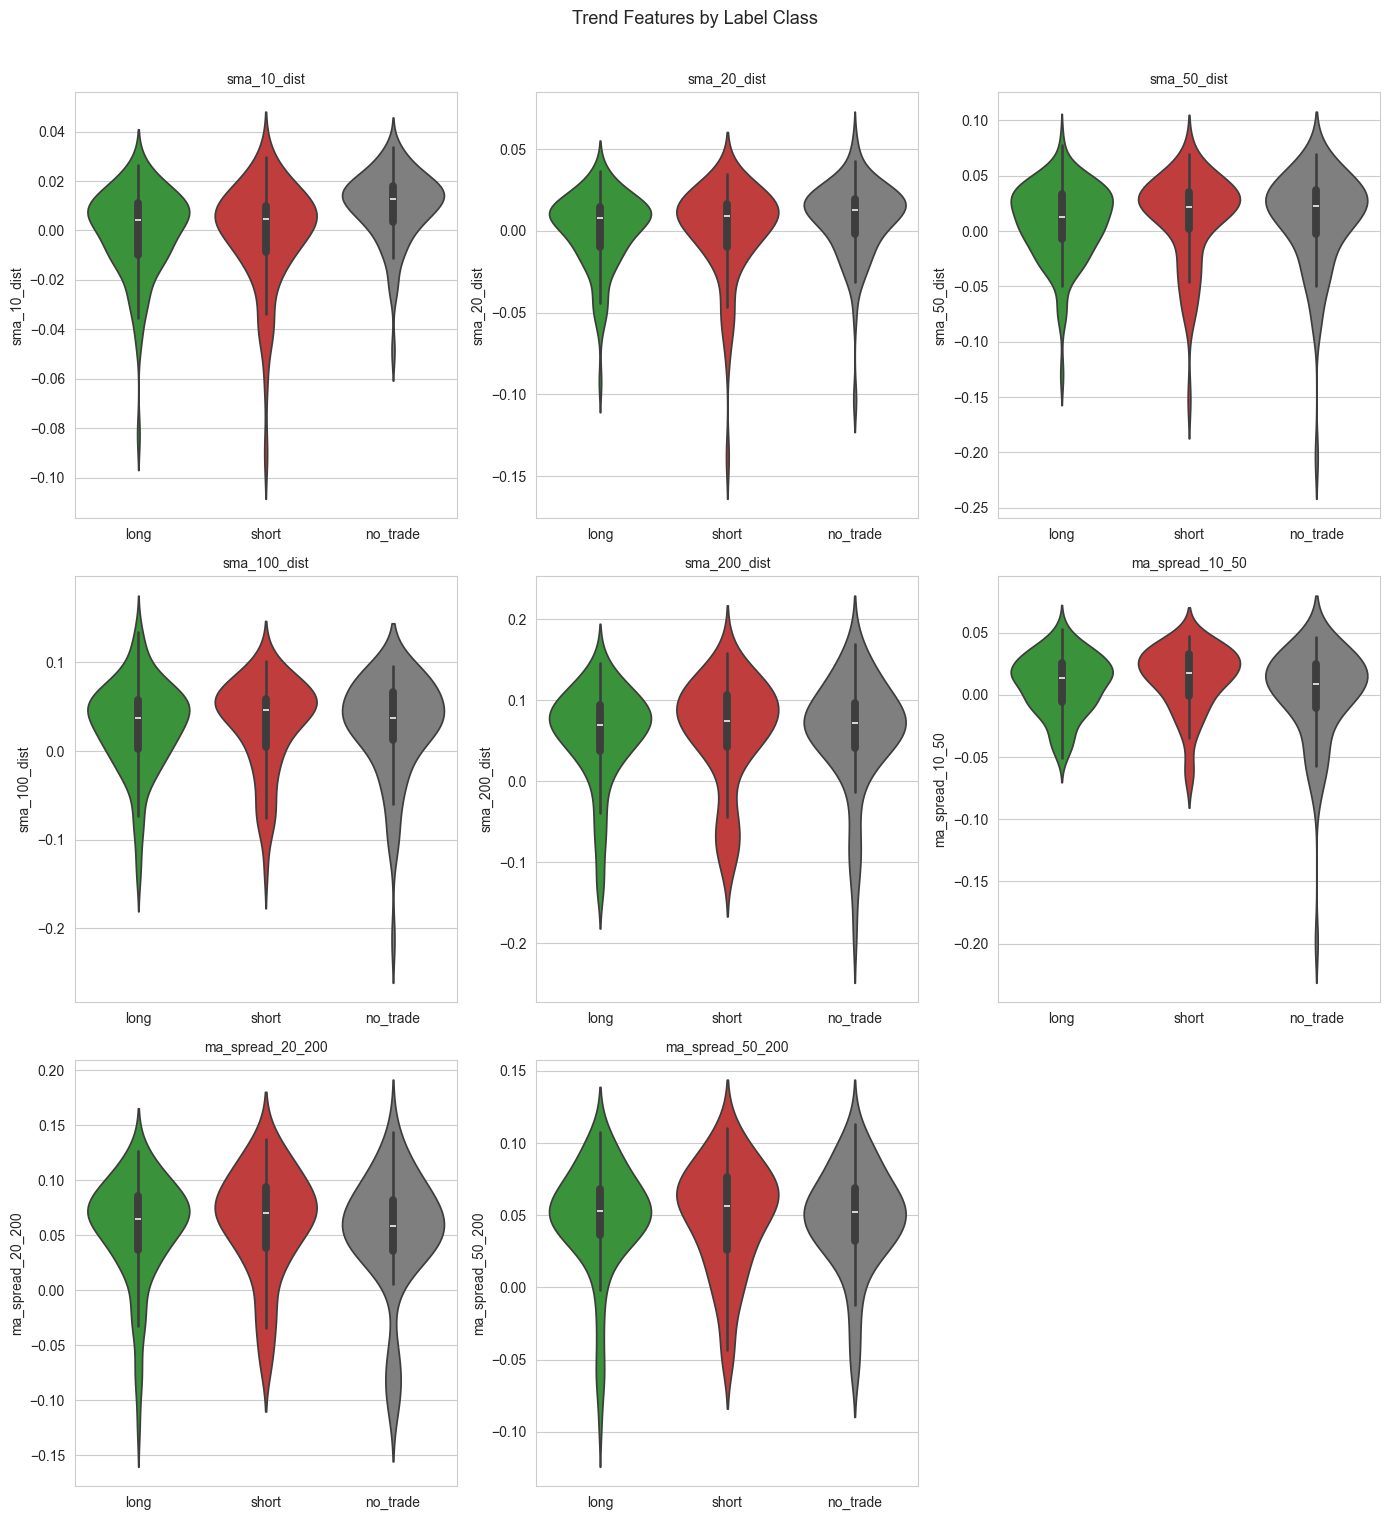

In [15]:
trend_features = [
    'sma_10_dist', 'sma_20_dist', 'sma_50_dist',
    'sma_100_dist', 'sma_200_dist',
    'ma_spread_10_50', 'ma_spread_20_200', 'ma_spread_50_200',
]
violin_grid(trend_features, 'Trend Features by Label Class', ncols=3, figsize=(14, 5))

**Interpretation:** Trend features measure where price sits relative to its moving averages.
Positive SMA distance means price is above the average (bullish context).
If long-labeled events cluster at higher SMA distances, it confirms that bullish setups
tend to resolve upward.

### 6.2 Volatility Features

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19

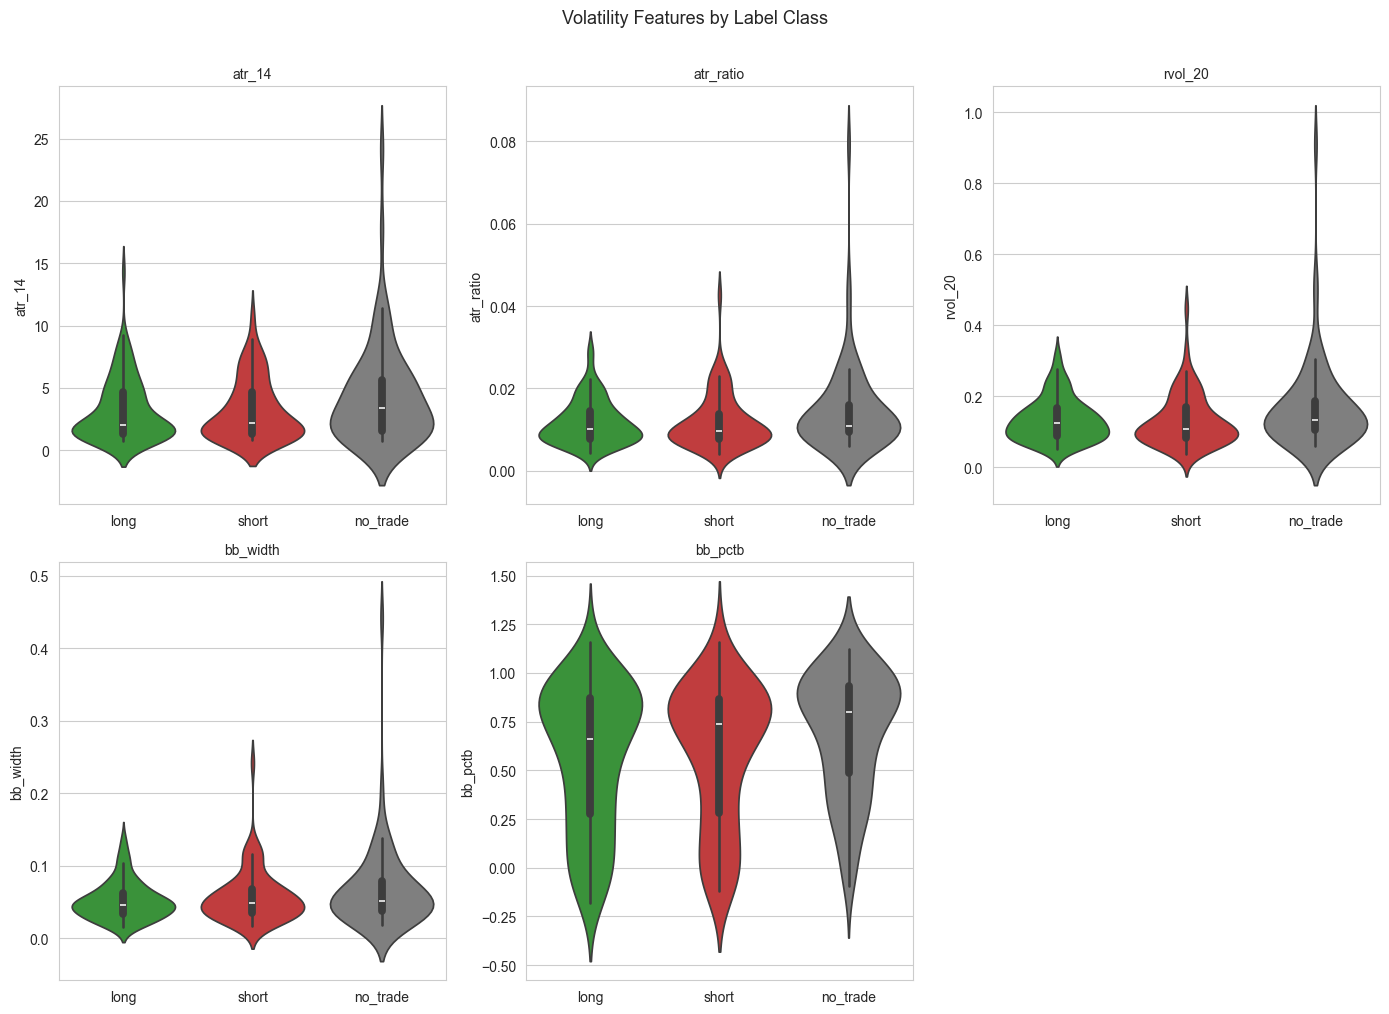

In [16]:
vol_features = ['atr_14', 'atr_ratio', 'rvol_20', 'bb_width', 'bb_pctb']
violin_grid(vol_features, 'Volatility Features by Label Class', ncols=3, figsize=(14, 5))

**Interpretation:** Volatility features capture the market environment at event time.
- `atr_ratio` normalises volatility by price level, making it comparable across the 15-year sample.
- `bb_pctb` indicates where price sits within its Bollinger Bands: near 1.0 = upper band,
  near 0.0 = lower band. If short labels cluster near the upper band, it signals mean reversion.
- `bb_width` captures volatility squeezes (narrow bands precede breakouts).

### 6.3 Momentum Features

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,


/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19

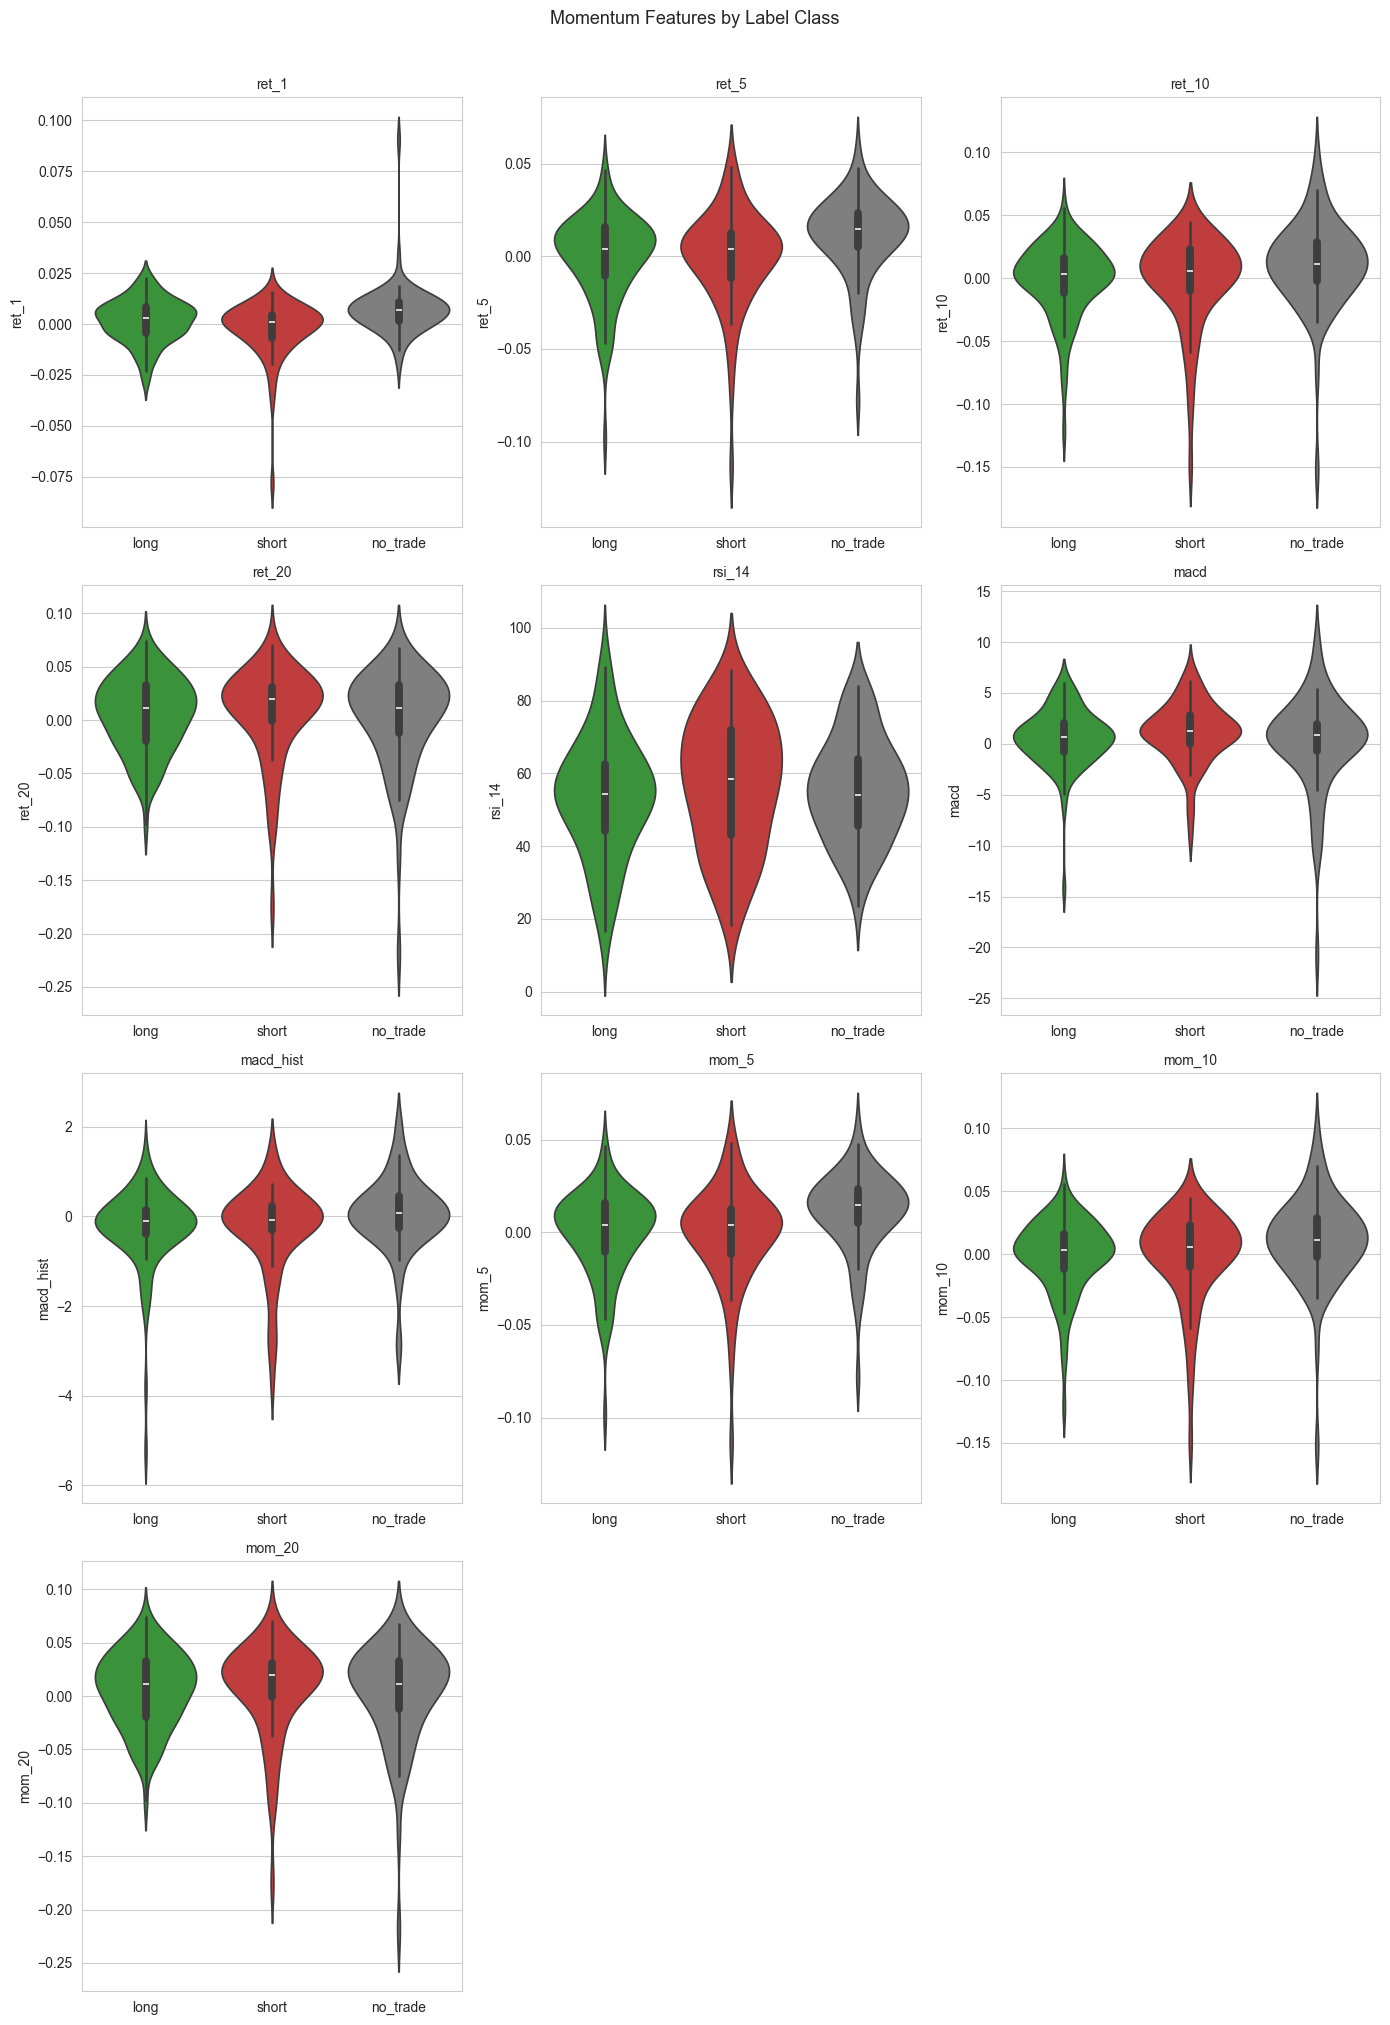

In [17]:
mom_features = [
    'ret_1', 'ret_5', 'ret_10', 'ret_20',
    'rsi_14', 'macd', 'macd_hist',
    'mom_5', 'mom_10', 'mom_20',
]
violin_grid(mom_features, 'Momentum Features by Label Class', ncols=3, figsize=(14, 5))

**Interpretation:** Momentum features capture the speed and direction of recent price moves.
- Returns over multiple horizons show whether the event occurs during a run-up or pullback.
- RSI flags overbought/oversold conditions. Events near RSI extremes may resolve differently.
- MACD histogram captures momentum acceleration: positive = strengthening uptrend.

### 6.4 Volume Features

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/1588101085.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y=feat, data=data,


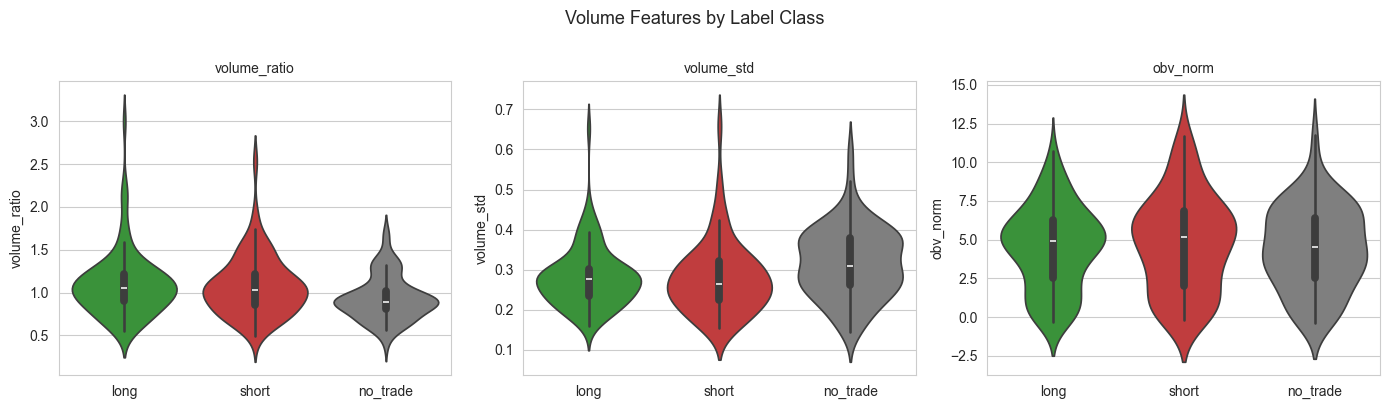

In [18]:
vol_feat = ['volume_ratio', 'volume_std', 'obv_norm']
violin_grid(vol_feat, 'Volume Features by Label Class', ncols=3, figsize=(14, 4))

**Interpretation:** Volume features proxy for institutional participation.
- `volume_ratio` > 1 means above-average volume (conviction behind the move).
- `obv_norm` tracks cumulative buying/selling pressure normalised by recent volume.
  Divergences between price and OBV often foreshadow reversals.

### 6.5 Pattern Geometry Features

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/26823

Events with pattern geometry: 121 / 221


/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/2682338281.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/26823

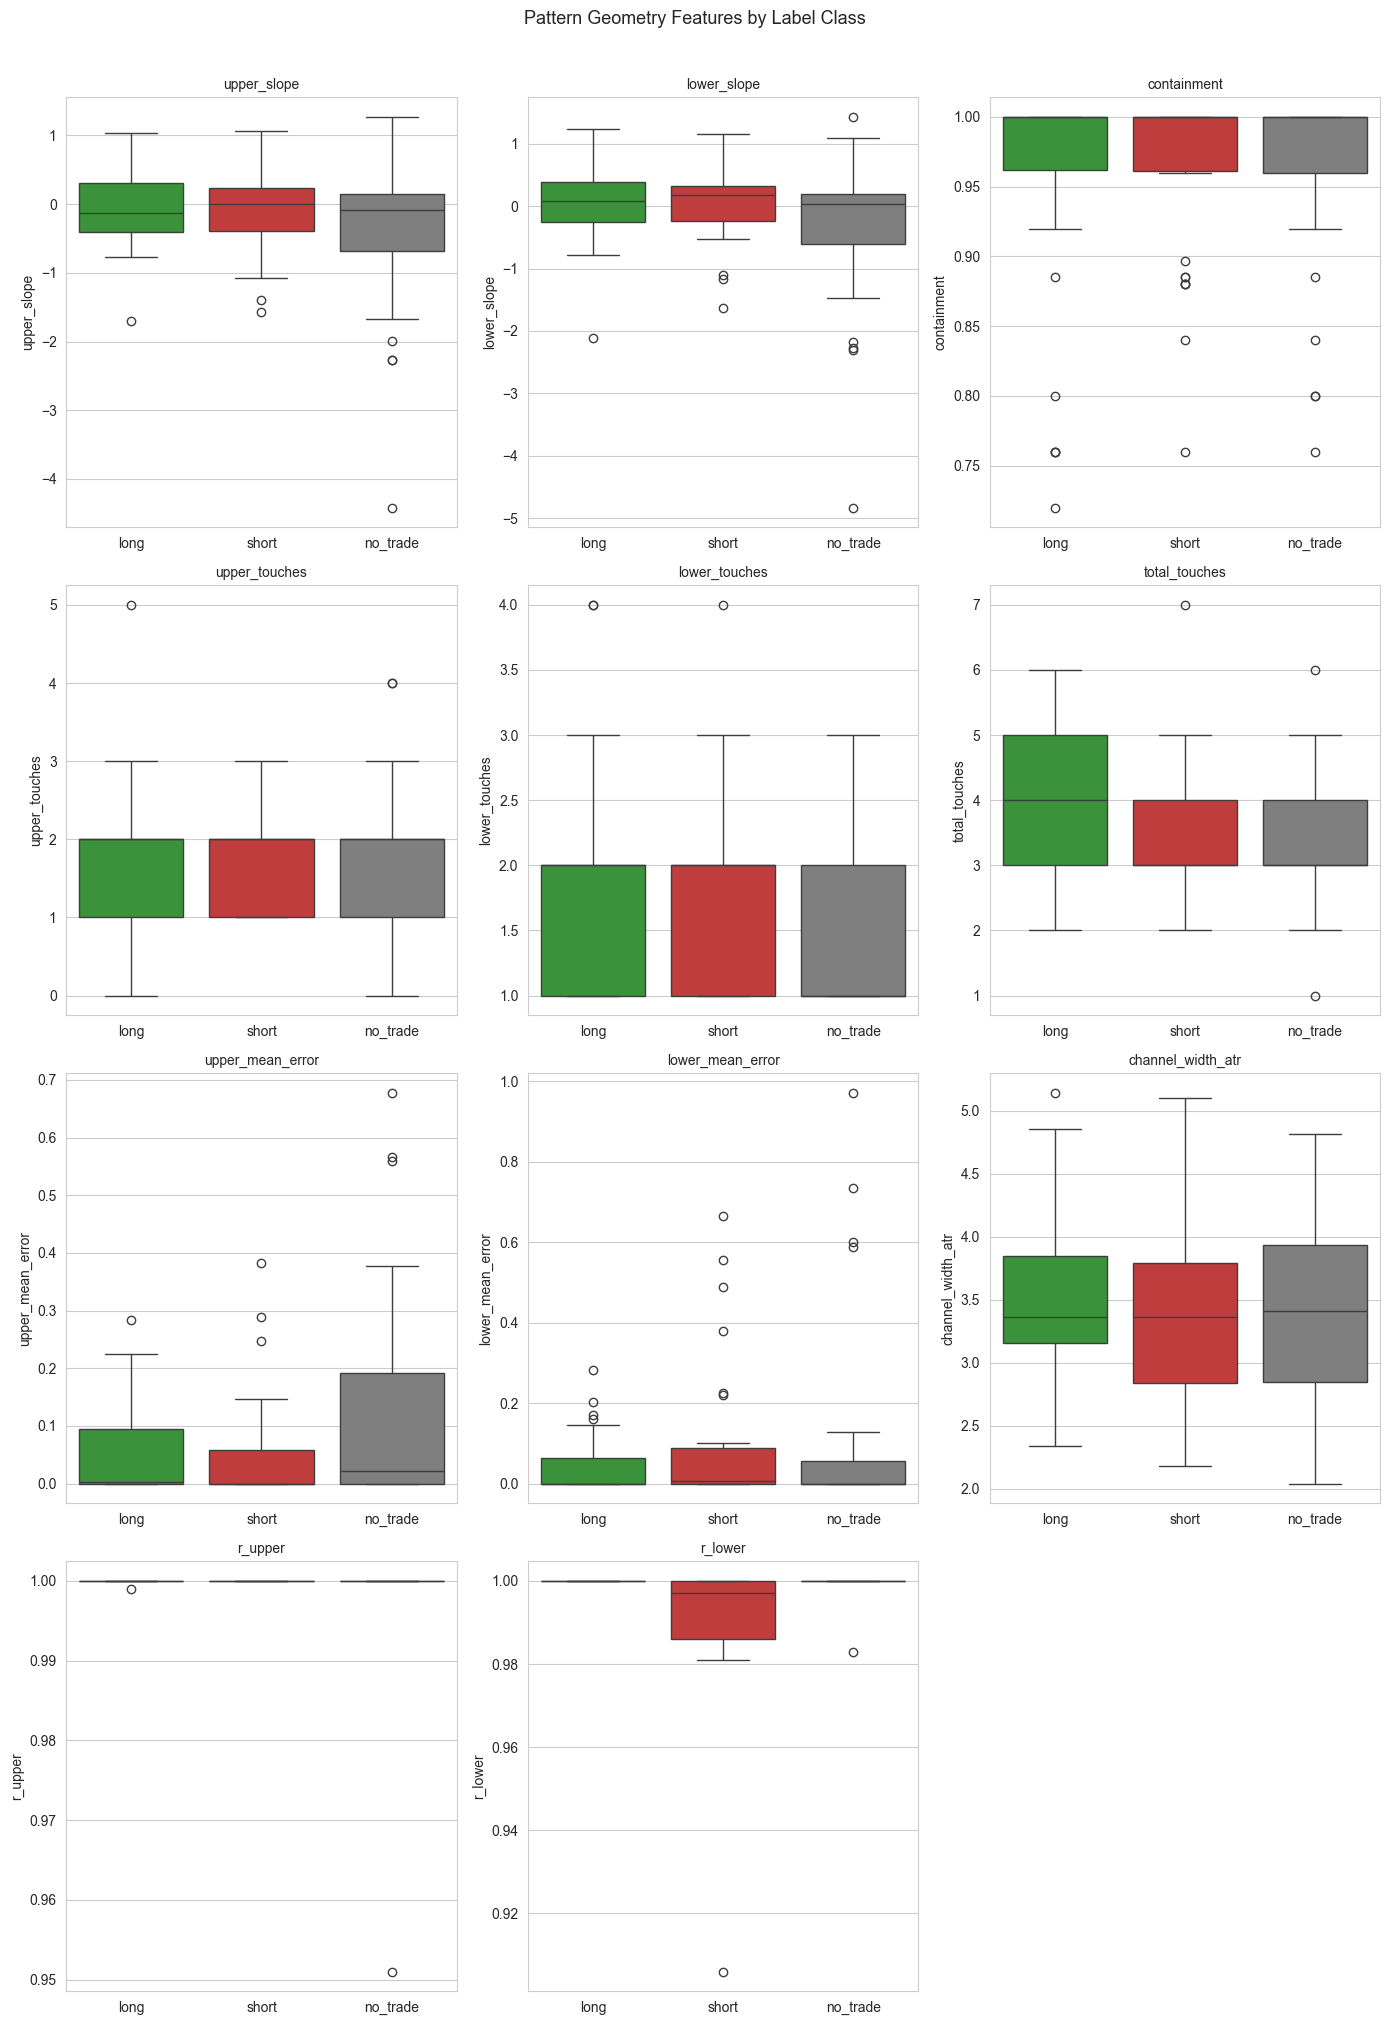

In [19]:
geo_features = [
    'upper_slope', 'lower_slope', 'containment',
    'upper_touches', 'lower_touches', 'total_touches',
    'upper_mean_error', 'lower_mean_error',
    'channel_width_atr', 'r_upper', 'r_lower',
]
geo_present = [f for f in geo_features if f in features.columns]

if geo_present:
    # Only events with geometry (triangles, channels)
    geo_data = plot_df[plot_df[geo_present[0]].notna()].copy()
    n_geo = len(geo_data)
    print(f'Events with pattern geometry: {n_geo} / {len(plot_df)}')
    if n_geo >= 5:
        nrows_g = int(np.ceil(len(geo_present) / 3))
        fig, axes = plt.subplots(nrows_g, 3, figsize=(14, 5 * nrows_g))
        axes = np.atleast_2d(axes)
        for idx, feat in enumerate(geo_present):
            r, c = divmod(idx, 3)
            ax = axes[r, c]
            data = geo_data[[feat, 'label']].dropna()
            if len(data) >= 3:
                sns.boxplot(x='label', y=feat, data=data,
                            order=label_order, palette=colors, ax=ax)
            ax.set_title(feat, fontsize=10)
            ax.set_xlabel('')
        for idx in range(len(geo_present), nrows_g * 3):
            r, c = divmod(idx, 3)
            axes[r, c].set_visible(False)
        fig.suptitle('Pattern Geometry Features by Label Class', fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()
    else:
        print('Too few geometry events for meaningful plots.')
else:
    print('No pattern geometry features in the feature matrix.')

**Interpretation:** Pattern geometry features describe the shape of the detected formation:
- `upper_slope` / `lower_slope`: direction of trendlines (converging, parallel, diverging)
- `containment`: what fraction of bars fall within the pattern boundaries
- `total_touches`: how many pivot points anchor the trendlines (more = stronger pattern)
- `channel_width_atr`: pattern width normalised by ATR (narrow = squeeze, wide = range)
- `r_upper` / `r_lower`: correlation of trendline fit (higher = cleaner pattern)

These features are only populated for triangle and channel events (NaN for S/R and multi-top/bottom).

### 6.6 Event Type Features

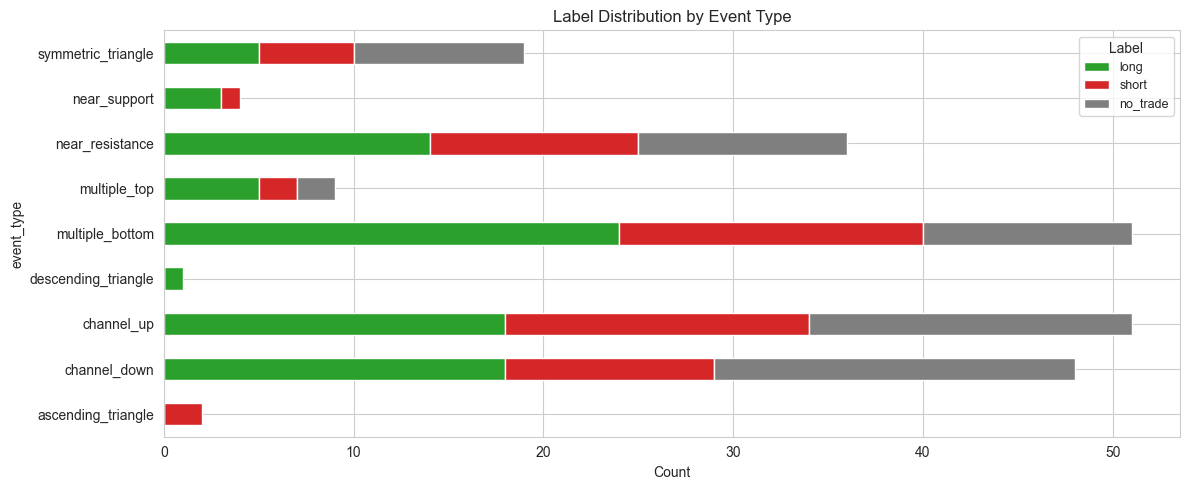

Event type dummy columns: ['etype_ascending_triangle', 'etype_channel_down', 'etype_channel_up', 'etype_descending_triangle', 'etype_multiple_bottom', 'etype_multiple_top', 'etype_near_resistance', 'etype_near_support', 'etype_symmetric_triangle']

Cross-tabulation:
label                long  short  no_trade
event_type                                
ascending_triangle      0      2         0
channel_down           18     11        19
channel_up             18     16        17
descending_triangle     1      0         0
multiple_bottom        24     16        11
multiple_top            5      2         2
near_resistance        14     11        11
near_support            3      1         0
symmetric_triangle      5      5         9


In [20]:
etype_cols = [c for c in features.columns if c.startswith('etype_')]

if etype_cols:
    # Cross-tabulation: event type vs label
    etype_label = pd.DataFrame({
        'event_type': labeled_df['event_type'].values,
        'label': labels.values,
    })
    ct = pd.crosstab(etype_label['event_type'], etype_label['label'])
    ct = ct.reindex(columns=label_order, fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, 5))
    ct.plot.barh(ax=ax, stacked=True, color=[colors[l] for l in label_order],
                 edgecolor='white')
    ax.set_xlabel('Count')
    ax.set_title('Label Distribution by Event Type')
    ax.legend(title='Label', fontsize=9)
    plt.tight_layout()
    plt.show()
    
    print('Event type dummy columns:', etype_cols)
    print(f'\nCross-tabulation:')
    print(ct.to_string())
else:
    print('No event-type dummy columns found.')

**Interpretation:** Event-type dummies encode *which* pattern detector fired.  
Different event types (support touch, resistance touch, channel breakout, etc.) may have
systematically different label distributions. One-hot encoding lets the model learn
type-specific biases without imposing an ordinal relationship.

---

## 7. Feature Importance: ANOVA F-Statistic

The ANOVA F-statistic measures how well a single feature separates the three classes.
Higher F = greater between-class variance relative to within-class variance.
This is a univariate filter; it does not capture feature interactions.

In [21]:
from sklearn.feature_selection import f_classif

# Use only numeric features with enough non-NaN values
numeric_feats = features.select_dtypes(include=[np.number]).columns.tolist()

# Drop features with >50% missing to avoid misleading F-scores
valid_feats = [f for f in numeric_feats if features[f].notna().sum() > len(features) * 0.5]

# Fill remaining NaN with column median for F-test (does not affect the model pipeline)
X_test = features[valid_feats].fillna(features[valid_feats].median())
y_test = labels.values

f_scores, p_values = f_classif(X_test, y_test)

anova_df = pd.DataFrame({
    'feature': valid_feats,
    'F_score': np.round(f_scores, 3),
    'p_value': p_values,
}).sort_values('F_score', ascending=False).reset_index(drop=True)

anova_df['significant'] = anova_df['p_value'] < 0.05

print(f'ANOVA F-test results ({len(anova_df)} features):')
print(f'  Significant (p < 0.05): {anova_df["significant"].sum()}')
print(f'  Not significant:        {(~anova_df["significant"]).sum()}')
print()
anova_df.head(20)

ANOVA F-test results (43 features):
  Significant (p < 0.05): 17
  Not significant:        26



,feature,F_score,p_value,significant
0,ret_1,10.180,0.000059,True
1,sma_10_dist,9.163,0.000151,True
2,mom_5,6.037,0.002806,True
3,ret_5,6.037,0.002806,True
4,upper_mean_error,5.835,0.003399,True
5,volume_ratio,4.862,0.008592,True
6,volume_std,4.713,0.009914,True
7,rvol_20,3.872,0.022258,True
8,ret_10,3.726,0.025634,True
9,mom_10,3.726,0.025634,True


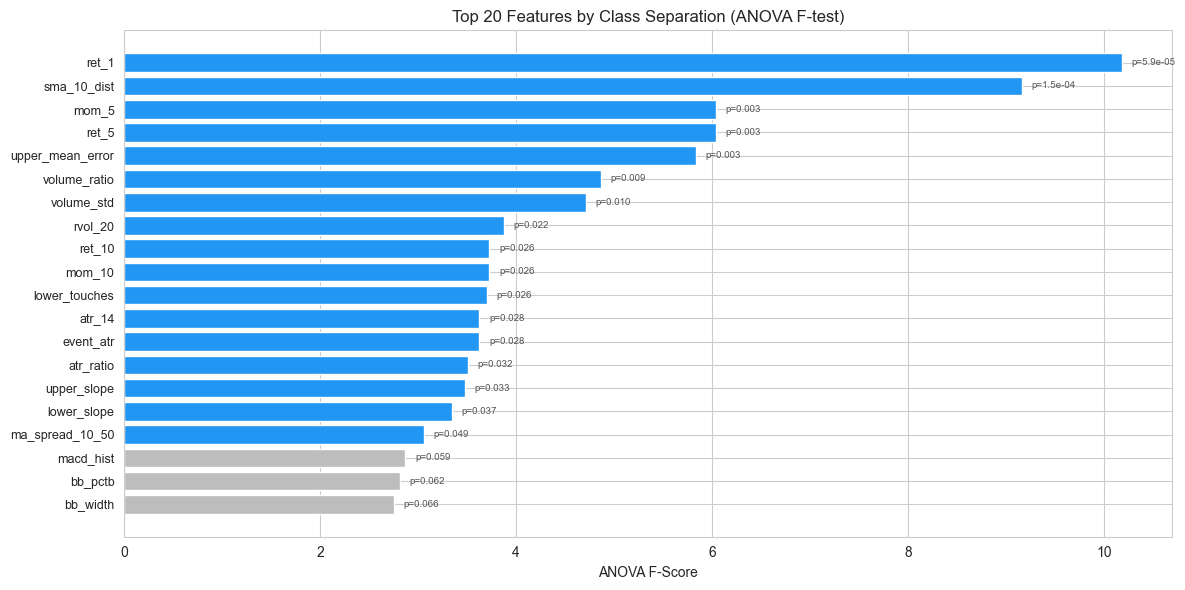


Blue bars = statistically significant (p < 0.05)
Grey bars = not significant


In [22]:
# Bar chart of top 20 features by F-score
top_n = min(20, len(anova_df))
top = anova_df.head(top_n)

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ['#2196F3' if sig else '#BDBDBD' for sig in top['significant']]
ax.barh(range(top_n), top['F_score'].values, color=bar_colors, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top['feature'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('ANOVA F-Score')
ax.set_title(f'Top {top_n} Features by Class Separation (ANOVA F-test)')

# Add p-value annotations
for i, (f_val, p_val) in enumerate(zip(top['F_score'], top['p_value'])):
    p_str = f'p={p_val:.3f}' if p_val >= 0.001 else f'p={p_val:.1e}'
    ax.text(f_val + 0.1, i, p_str, va='center', fontsize=7, color='#555')

plt.tight_layout()
plt.show()

print('\nBlue bars = statistically significant (p < 0.05)')
print('Grey bars = not significant')

/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/3348425306.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/3348425306.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/3348425306.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y=feat, data=data,
/var/folders/tg/hdvft4mx4tdg8h41qnv7s_r80000gn/T/ipykernel_19814/33484

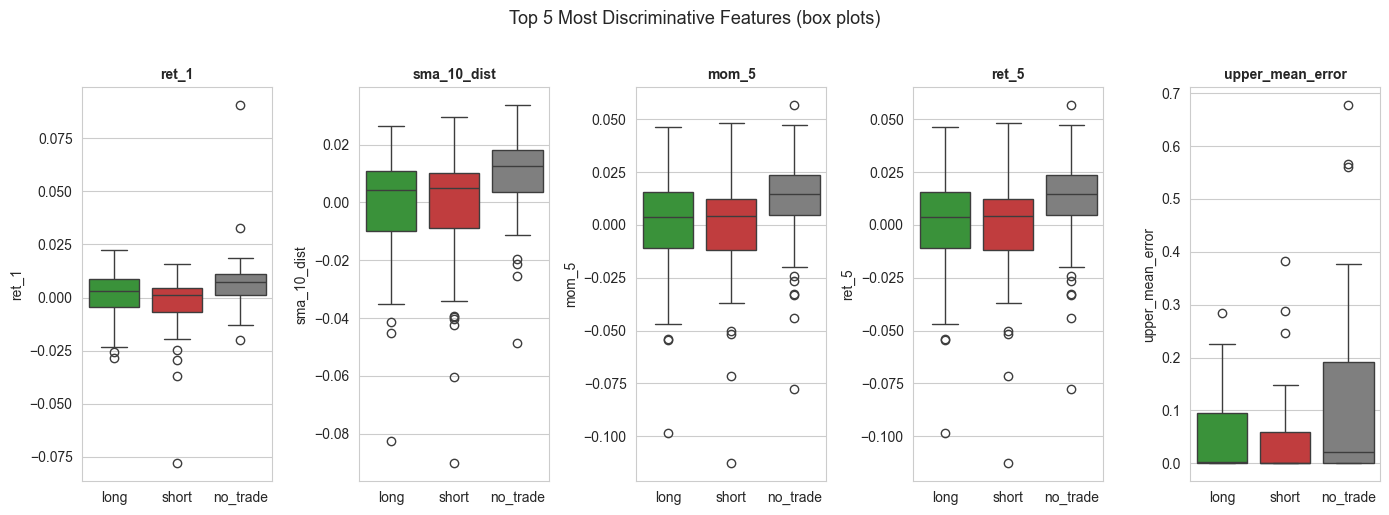

In [23]:
# Detailed look at the top 5 most discriminative features
top5 = anova_df.head(5)['feature'].tolist()
top5 = [f for f in top5 if f in plot_df.columns]

if top5:
    fig, axes = plt.subplots(1, len(top5), figsize=(14, 5))
    if len(top5) == 1:
        axes = [axes]
    for ax, feat in zip(axes, top5):
        data = plot_df[[feat, 'label']].dropna()
        sns.boxplot(x='label', y=feat, data=data,
                    order=label_order, palette=colors, ax=ax)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('')
    fig.suptitle('Top 5 Most Discriminative Features (box plots)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

---

## 8. Lookahead Bias Prevention

Lookahead bias occurs when features at time *t* use information from after *t*.  
This inflates backtested performance and produces models that fail in production.

### How we prevent it

| Component | Lookahead Prevention Mechanism |
|-----------|-------------------------------|
| **Technical indicators** | Every indicator uses a backward-looking rolling window. Value at bar *i* depends only on bars 0...*i*. No forward-looking functions (e.g., `shift(-1)`) are used anywhere in `indicators.py`. |
| **Pattern detection** | The scanner detects patterns using a lookback window ending at the current bar. A triangle at bar *t* is identified from pivots in bars `t-window...t`. |
| **Triple-barrier labels** | Labels are the *target*, not a feature. They use future bars by design (that is the dependent variable). They are never leaked into the feature matrix. |
| **Feature extraction** | `build_feature_matrix` extracts indicator values at the event date. It does not peek at future bars to compute features. |
| **Train/test split** | Will use time-based (purged) cross-validation in Phase 7 to prevent information leakage between folds. |
| **SMA / EMA** | All moving averages use `rolling().mean()` or `ewm(adjust=False).mean()`, which are causal filters. |
| **Volume normalisation** | `volume_ratio` divides by a trailing 20-bar average, not a centred window. |
| **ATR** | Computed with a trailing rolling window of 14 bars. |

### What to watch for

- **Label leakage:** Features like `return_pct` or `exit_price` from the labeled DataFrame must never enter the feature matrix. They encode the outcome.
- **Centred windows:** Avoid `rolling(..., center=True)` which would use future bars.
- **Same-bar information:** Entry price is available at the event bar (it is the Close price), so including it is valid.

All code in `src/features/indicators.py` has been audited and uses only backward-looking computations.

In [24]:
# Verify: no label information leaked into features
forbidden_cols = ['label', 'return_pct', 'exit_price', 'exit_date',
                  'upper_barrier', 'lower_barrier', 'bars_held']
leaked = [c for c in forbidden_cols if c in features.columns]

if leaked:
    print(f'WARNING: Label leakage detected! Columns in feature matrix: {leaked}')
else:
    print('Lookahead check PASSED: no label/outcome columns in the feature matrix.')

print(f'\nFeature columns: {list(features.columns)}')

Lookahead check PASSED: no label/outcome columns in the feature matrix.

Feature columns: ['atr_14', 'atr_ratio', 'rvol_20', 'ret_1', 'ret_5', 'ret_10', 'ret_20', 'sma_10', 'sma_10_dist', 'sma_20', 'sma_20_dist', 'sma_50', 'sma_50_dist', 'sma_100', 'sma_100_dist', 'sma_200', 'sma_200_dist', 'ma_spread_10_50', 'ma_spread_20_200', 'ma_spread_50_200', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'bb_pctb', 'mom_5', 'mom_10', 'mom_20', 'volume_ratio', 'volume_std', 'obv_norm', 'upper_slope', 'lower_slope', 'containment', 'upper_touches', 'lower_touches', 'total_touches', 'upper_mean_error', 'lower_mean_error', 'pattern_window', 'channel_width_atr', 'r_upper', 'r_lower', 'etype_ascending_triangle', 'etype_channel_down', 'etype_channel_up', 'etype_descending_triangle', 'etype_multiple_bottom', 'etype_multiple_top', 'etype_near_resistance', 'etype_near_support', 'etype_symmetric_triangle', 'entry_price', 'event_atr']


---

## 9. Summary Table of All Features

A clean reference table for the thesis, listing every feature in the matrix.

In [25]:
# Build a comprehensive summary table
feature_info = {
    # Volatility
    'atr_14':          ('Volatility', '14-bar Average True Range'),
    'atr_ratio':       ('Volatility', 'ATR normalised by Close price'),
    'rvol_20':         ('Volatility', '20-bar annualised rolling volatility'),
    'bb_width':        ('Volatility', 'Bollinger Band width / SMA20'),
    'bb_pctb':         ('Volatility', 'Bollinger %B (position within bands)'),
    # Trend
    'sma_10':          ('Trend', '10-bar simple moving average'),
    'sma_10_dist':     ('Trend', 'Relative distance from SMA10'),
    'sma_20':          ('Trend', '20-bar simple moving average'),
    'sma_20_dist':     ('Trend', 'Relative distance from SMA20'),
    'sma_50':          ('Trend', '50-bar simple moving average'),
    'sma_50_dist':     ('Trend', 'Relative distance from SMA50'),
    'sma_100':         ('Trend', '100-bar simple moving average'),
    'sma_100_dist':    ('Trend', 'Relative distance from SMA100'),
    'sma_200':         ('Trend', '200-bar simple moving average'),
    'sma_200_dist':    ('Trend', 'Relative distance from SMA200'),
    'ma_spread_10_50': ('Trend', 'SMA10-SMA50 spread (normalised)'),
    'ma_spread_20_200':('Trend', 'SMA20-SMA200 spread (normalised)'),
    'ma_spread_50_200':('Trend', 'SMA50-SMA200 spread (golden/death cross)'),
    # Momentum
    'ret_1':           ('Momentum', '1-bar simple return'),
    'ret_5':           ('Momentum', '5-bar simple return'),
    'ret_10':          ('Momentum', '10-bar simple return'),
    'ret_20':          ('Momentum', '20-bar simple return'),
    'rsi_14':          ('Momentum', '14-bar Relative Strength Index'),
    'macd':            ('Momentum', 'MACD line (EMA12 - EMA26)'),
    'macd_signal':     ('Momentum', '9-bar EMA of MACD line'),
    'macd_hist':       ('Momentum', 'MACD histogram (momentum acceleration)'),
    'mom_5':           ('Momentum', '5-bar rate of change'),
    'mom_10':          ('Momentum', '10-bar rate of change'),
    'mom_20':          ('Momentum', '20-bar rate of change'),
    # Volume
    'volume_ratio':    ('Volume', 'Volume / 20-bar volume MA'),
    'volume_std':      ('Volume', 'Volume rolling std / volume MA'),
    'obv_norm':        ('Volume', 'Normalised on-balance volume'),
    # Pattern Geometry
    'upper_slope':     ('Pattern Geometry', 'Upper trendline slope'),
    'lower_slope':     ('Pattern Geometry', 'Lower trendline slope'),
    'containment':     ('Pattern Geometry', 'Fraction of bars within pattern bounds'),
    'upper_touches':   ('Pattern Geometry', 'Number of upper trendline touches'),
    'lower_touches':   ('Pattern Geometry', 'Number of lower trendline touches'),
    'total_touches':   ('Pattern Geometry', 'Total trendline touches'),
    'upper_mean_error':('Pattern Geometry', 'Mean error of upper trendline fit'),
    'lower_mean_error':('Pattern Geometry', 'Mean error of lower trendline fit'),
    'pattern_window':  ('Pattern Geometry', 'Lookback window of detected pattern'),
    'channel_width_atr':('Pattern Geometry', 'Channel width normalised by ATR'),
    'r_upper':         ('Pattern Geometry', 'Correlation of upper trendline fit'),
    'r_lower':         ('Pattern Geometry', 'Correlation of lower trendline fit'),
    # Event Meta
    'entry_price':     ('Event Meta', 'Close price at event bar'),
    'event_atr':       ('Event Meta', 'ATR value at event bar'),
}

# Build table for columns actually in the matrix
rows = []
for col in features.columns:
    if col in feature_info:
        group, desc = feature_info[col]
    elif col.startswith('etype_'):
        group = 'Event Type'
        desc = f'Dummy: event type = {col.replace("etype_", "")}'
    else:
        group = 'Other'
        desc = col
    
    n_valid = features[col].notna().sum()
    rows.append({
        'Feature': col,
        'Group': group,
        'Description': desc,
        'Valid': n_valid,
        'Missing': len(features) - n_valid,
    })

summary_table = pd.DataFrame(rows)
summary_table.index = range(1, len(summary_table) + 1)
summary_table.index.name = '#'

print(f'Total features in matrix: {len(summary_table)}')
print(f'Feature groups: {summary_table["Group"].nunique()}')
print()
summary_table

Total features in matrix: 55
Feature groups: 7



,Feature,Group,Description,Valid,Missing
#,,,,,
1,atr_14,Volatility,14-bar Average True Range,221,0
2,atr_ratio,Volatility,ATR normalised by Close price,221,0
3,rvol_20,Volatility,20-bar annualised rolling volatility,221,0
4,ret_1,Momentum,1-bar simple return,221,0
5,ret_5,Momentum,5-bar simple return,221,0
6,ret_10,Momentum,10-bar simple return,221,0
7,ret_20,Momentum,20-bar simple return,221,0
8,sma_10,Trend,10-bar simple moving average,221,0
9,sma_10_dist,Trend,Relative distance from SMA10,221,0


In [26]:
# Group-level summary
group_summary = summary_table.groupby('Group').agg(
    count=('Feature', 'size'),
    features=('Feature', lambda x: ', '.join(x)),
).sort_values('count', ascending=False)

print('Features per group:')
for grp, row in group_summary.iterrows():
    print(f'  {grp:20s}  {row["count"]:>2d}  [{row["features"]}]')

Features per group:
  Trend                 13  [sma_10, sma_10_dist, sma_20, sma_20_dist, sma_50, sma_50_dist, sma_100, sma_100_dist, sma_200, sma_200_dist, ma_spread_10_50, ma_spread_20_200, ma_spread_50_200]
  Pattern Geometry      12  [upper_slope, lower_slope, containment, upper_touches, lower_touches, total_touches, upper_mean_error, lower_mean_error, pattern_window, channel_width_atr, r_upper, r_lower]
  Momentum              11  [ret_1, ret_5, ret_10, ret_20, rsi_14, macd, macd_signal, macd_hist, mom_5, mom_10, mom_20]
  Event Type             9  [etype_ascending_triangle, etype_channel_down, etype_channel_up, etype_descending_triangle, etype_multiple_bottom, etype_multiple_top, etype_near_resistance, etype_near_support, etype_symmetric_triangle]
  Volatility             5  [atr_14, atr_ratio, rvol_20, bb_width, bb_pctb]
  Volume                 3  [volume_ratio, volume_std, obv_norm]
  Event Meta             2  [entry_price, event_atr]


---

## Conclusion and Next Steps

**What was done:**
- Built a complete event-level feature matrix using `src/features/build_features.py`
- Computed 32+ technical indicators across 6 groups: trend, volatility, momentum, volume, pattern geometry, and event type
- Verified no lookahead bias in any feature computation
- Analysed feature distributions by label class to identify discriminative features
- Ranked features by ANOVA F-statistic for univariate class separation

**Key findings:**
- The feature matrix has good coverage, with most indicators fully populated for all events
- Pattern geometry features are naturally sparse (only populated for triangle/channel events)
- Several momentum and trend features show meaningful separation between long/short/no_trade classes
- Highly correlated feature pairs exist (e.g., SMA distances at different horizons), but Random Forests handle this robustly
- No label leakage was detected in the feature matrix

**Design choices:**
- All indicators are backward-looking (no `center=True`, no future shifts)
- SMA distances are normalised (divided by the SMA) for cross-period comparability
- ATR-based normalisation ensures volatility features work across the full 2010-2025 sample
- Event-type dummies allow the model to learn pattern-specific biases

**Next step:** Phase 7 -- train a Random Forest classifier on this feature matrix with purged time-series cross-validation.